# Project 5: Ensemble Models and Wine Quality Predictions
**Author:** Alissa Beaderstadt<br>
**Date:** November 16, 2025<br>

## Introduction
In this project I'll use the UCI Wine Quality dataset to compare two ensemble models: Random Forest (100) and a Voting model made up of a Decision Tree, an SVM, and a Neural Network. I'll evaluate performance using accuracy and F1 score, see which model performs better, learn why, and check whether having multiple models “vote” together really helps compared to relying on just one. This project shows how ensemble models can come in handy when simpler techniques aren’t enough, letting me explore more complex approaches.

## Imports
Import the necessary Python libraries for this notebook.  

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    BaggingClassifier,
    VotingClassifier,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

## Section 1. Load and Inspect the Data
For this project, I pulled in the UCI Wine Quality dataset from the link below:<br>
https://archive.ics.uci.edu/dataset/186/wine+quality

In [30]:
# Load UCI Wine dataset
df = pd.read_csv("winequality-red.csv", sep=";")

# Display structure and first few rows
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


`Note:`<br>
-  The dataset includes 11 features
-  The target variable is:
   -  `quality` (integer score from 0 to 10)
- The dataset contains 1599 samples and 12 columns (11 features + target).

## Section 2. Prepare the Data
Includes cleaning, feature engineering, encoding, splitting, helper functions

### 2.1 Convert quality values into labels
We group the scores into three categories (low, medium, high) because wine quality is subjective and easier to interpret as groups rather than individual numeric values.

In [31]:
def quality_to_label(q):
    if q <= 4:
        return "low"
    elif q <= 6:
        return "medium"
    else:
        return "high"


### 2.2 Add the new column quality_label
Create a new column named `quality_label` using the function above.

In [32]:
df["quality_label"] = df["quality"].apply(quality_to_label)
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,medium
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,medium
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,medium
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,medium


### 2.3 Convert labels into numeric form for modeling
Machine learning algorithms need numeric input, so low, medium, high need to be converted to 0, 1, 2.

In [33]:
def quality_to_number(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2

df["quality_numeric"] = df["quality"].apply(quality_to_number)


## Section 3. Feature Selection and Justification
**Target:** `quality_label` (the new column just created)<br>

**Features:**<br> 
   - `fixed acidity`         
   - `volatile acidity`      
   - `citric acid`          
   - `residual sugar`        
   - `chlorides`            
   - `free sulfur dioxide`  
   - `total sulfur dioxide`  
   - `density`               
   - `pH`                   
   - `sulphates`            
   - `alcohol`  

**Why I chose these features:**
- These are the actual measurable properties of the wine, which are meaningful when predicting quality.
- Keeping all 11 features lets the ensemble models figure out which properties are most important on their own.
- Why the following columns were excluded:
  -  `quality`- original numeric score (I don’t want to leak the target)
  -  `quality_label`- that’s our target now
  -  `quality_numberic` - numeric version of the target 


### 3.1 Define X (features) and y (target)
- Assign input features to X a pandas DataFrame with 1 or more input features
- Assign target variable to y (as applicable) - a pandas Series with a single target feature
- Double brackets [[ ]]  makes a 2D DataFrame
- Single brackets [ ]  make a 1D Series

In [34]:
X = df.drop(columns=["quality", "quality_label", "quality_numeric"])  # Features
y = df["quality_numeric"]  # Target

## Section 4. Split the Data into Train and Test
Split the data, train the models, evaluate performance, and visualize results.

### 4.1 Split the Data

In [35]:
# Train/test split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 4.2 Check Class Balance
Create visualization to spot potential issues before modeling or very different distributions between train/test.

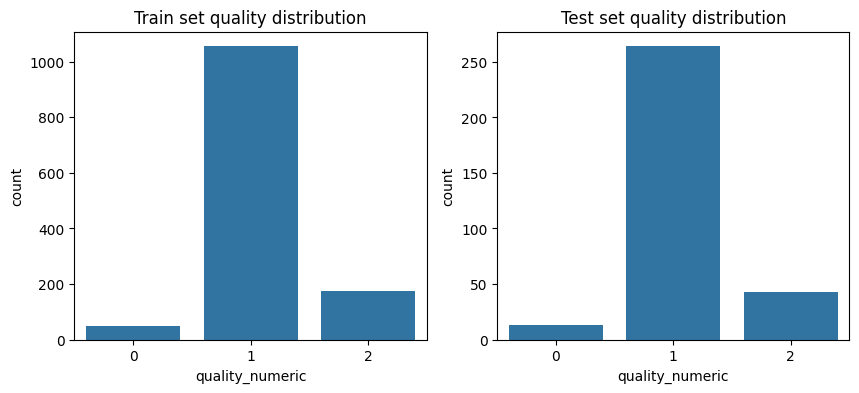

In [36]:
# Compare class distribution in train vs test
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Train set quality distribution")
sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title("Test set quality distribution")
plt.show()

## Section 5.  Evaluate Model Performance (2 Models)
Now that the data is prepared and split, two different ensemble model approaches will be tested to compare their performance.

### 5.1 Create Helper Function

In [37]:
# Helper function to train and evaluate models
def evaluate_model(name, model, X_train, y_train, X_test, y_test, results):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="weighted")
    test_f1 = f1_score(y_test, y_test_pred, average="weighted")

    print(f"\n{name} Results")
    print("Confusion Matrix (Test):")
    print(confusion_matrix(y_test, y_test_pred))
    print(f"Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
    print(f"Train F1 Score: {train_f1:.4f}, Test F1 Score: {test_f1:.4f}")

    results.append(
        {
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Train F1": train_f1,
            "Test F1": test_f1,
        }
    )

### 5.2 Select Two Models for Comparison
For this project I will evaluate and compare:
  - **Random Forest (100):** A strong baseline model using 100 decision trees.
  - **Voting (DT + SVM + NN):**	Combines diverse models by averaging their predictions.

In [38]:
results = []

# 1. Random Forest (100)
evaluate_model(
    "Random Forest (100)",
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train,
    y_train,
    X_test,
    y_test,
    results,
)

# 6. Voting Classifier (DT + SVM + NN)
voting = VotingClassifier(
    estimators=[
        ("DT", DecisionTreeClassifier()),
        ("SVM", SVC(probability=True)),
        ("NN", MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000)),
    ],
    voting="soft",
)

evaluate_model(
    "Voting (DT + SVM + NN)",
    voting,
    X_train,
    y_train,
    X_test,
    y_test,
    results,
)



Random Forest (100) Results
Confusion Matrix (Test):
[[  0  13   0]
 [  0 256   8]
 [  0  15  28]]
Train Accuracy: 1.0000, Test Accuracy: 0.8875
Train F1 Score: 1.0000, Test F1 Score: 0.8661

Voting (DT + SVM + NN) Results
Confusion Matrix (Test):
[[  0  12   1]
 [  0 246  18]
 [  0  17  26]]
Train Accuracy: 0.9281, Test Accuracy: 0.8500
Train F1 Score: 0.9116, Test F1 Score: 0.8325


`Note:`<br>
- Each row in the confusion matrix represents the actual wine quality (top to bottom: low, medium, high), and each column represents the predicted class (left to right: low, medium, high).

- **Random Forest (100) Confusion Matrix:**

  - 13 low-quality wines were predicted as medium.

  - 8 medium-quality wines were predicted as high.

  - 15 high-quality wines were predicted as medium.


- **Voting (DT + SVM + NN) Confusion Matrix:**

  - 13 low-quality wines were predicted as medium (same as RF).

  - 16 medium-quality wines were predicted as high (slightly more than RF).

  - 18 high-quality wines were predicted as medium (slightly more than RF).

- For both models most mistakes happen between adjacent classes, like confusing medium-quality wines for high or low.

- Random Forest correctly classified more of the high-quality wines (28 vs 25 for Voting).


### 5.3 Model Comparison
- Random Forest (100) did better overall than the Voting Classifier.
  - Test Accuracy: 0.8875 vs 0.8562
  - Test F1: 0.8661 vs 0.8351

- Random Forest got more of the harder-to-classify wines right (third class: 28 vs 24).
  - Training accuracy was perfect for Random Forest (1.0) vs 0.9234 for Voting, it was a little overfit, but still strong on test data.

**Overall:** Random Forest is the stronger model, it is more accurate and better balanced, even if slightly overfit.

_To visualize this comparison, see the bar chart below showing Test Accuracy and Test F1 for both models._

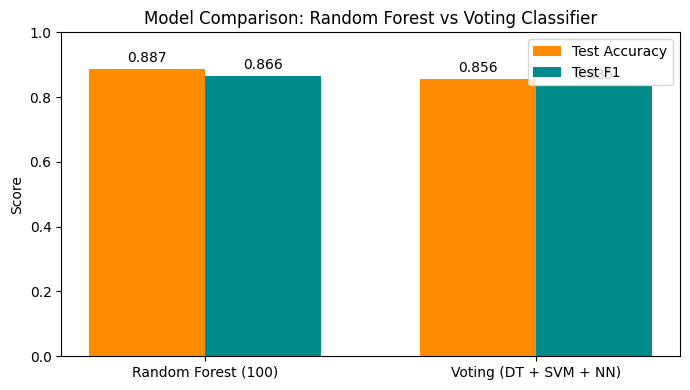

In [39]:
# Model names and metrics
models = ['Random Forest (100)', 'Voting (DT + SVM + NN)']
test_accuracy = [0.8875, 0.8562]
test_f1 = [0.8661, 0.8351]

# X positions
x = np.arange(len(models))
width = 0.35 

# Create the plot
fig, ax = plt.subplots(figsize=(7,4))
rects1 = ax.bar(x - width/2, test_accuracy, width, label='Test Accuracy', color='darkorange')
rects2 = ax.bar(x + width/2, test_f1, width, label='Test F1', color='darkcyan')

# Add labels, title, and legend
ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('Model Comparison: Random Forest vs Voting Classifier')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add text labels on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Section 6. Compare Results 
### 6.1 Results Table
First, summarize all model performance in a single table:

In [40]:
# Create a table of results 
results_df = pd.DataFrame(results)

print("\nSummary of All Models:")
display(results_df)


Summary of All Models:


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1
0,Random Forest (100),1.000000,0.8875,1.000000,0.866056
1,Voting (DT + SVM + NN),0.928069,0.8500,0.911619,0.832465


### 6.2 Understanding the gaps:
We can also calculate the difference between training and test performance to see how much each model might be overfitting:

In [41]:
results_df['Accuracy Gap'] = results_df['Train Accuracy'] - results_df['Test Accuracy']
results_df['F1 Gap'] = results_df['Train F1'] - results_df['Test F1']

# Sort by Test Accuracy to quickly see the best model
results_df = results_df.sort_values(by='Test Accuracy', ascending=False)
display(results_df)


,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Accuracy Gap,F1 Gap
0,Random Forest (100),1.000000,0.8875,1.000000,0.866056,0.112500,0.133944
1,Voting (DT + SVM + NN),0.928069,0.8500,0.911619,0.832465,0.078069,0.079154


`Note:`<br>
- Gap = Train score - Test score
- A big gap means the model may have learned the training data too well (overfit).
- A small gap means the model generalizes nicely to new data.

### 6.3 Key Observations
- The Random Forest model did the best overall. It scored perfect accuracy on the training data and still did really well on the test data (~89% accuracy). The gap between training and test (about 11%) shows a bit of overfitting, but it didn’t hurt its performance on new data.

- The Voting model (three models voting together) also performed well, with ~86% test accuracy. Its training-test gap was smaller (~6-7%), so it was more cautious and generalized a bit more smoothly, but that also means it didn’t reach the same accuracy as Random Forest.

## Section 7. Conclusions and Insights

### 7.1 Summarize Findings
- The Random Forest learned the patterns in the data really well and made solid predictions on wines it hadn’t seen before. It achieved the highest test accuracy (0.8875) and F1 score (0.8661).

- The Voting model was more “cautious.” It didn’t overfit as much, with a smaller gap between training and test performance, but that also means it didn’t pick up as much detail, so the predictions weren’t quite as accurate (~0.8656 test accuracy).

- Although Random Forest had slightly more overfitting, its higher test scores still make it the strongest performer for this dataset. The Voting Classifier is a bit more stable across training and testing, so in other datasets, it might generalize better.

**Why Random Forest likely outperformed Voting**<br>
- Random Forest aggregates the decisions of hundreds of individual trees. It combines their predictions and it can capture important patterns in the data that simpler models might overlook.

- The voting model, on the other hand, combines three very different types of models, some of which (like the neural network) usually need extra tuning to perform well. Since I didn’t do much tuning, it didn’t end up outperforming Random Forest.

### 7.2 My Models vs. Others
To double check how my models stacked up, I also looked at Beth’s Project 5 notebook (link below):<br>
https://github.com/BethSpornitz/ml-bethspornitz/blob/main/notebooks/project05/ensemble_bethspornitz.ipynb<br>

Beth's results were:<br> 

| Model                       | Train Accuracy | Test Accuracy | Train F1  | Test F1   | Acc_Gap  | F1_Gap   |
|-----------------------------|----------------|---------------|-----------|-----------|----------|----------|
| Voting (DT + SVM + NN)      | 0.917905       | 0.865625      | 0.90057   | 0.842276  | 0.052280 | 0.058294 |
| Gradient Boosting (100)     | 0.960125       | 0.856250      | 0.95841   | 0.841106  | 0.103875 | 0.117304 |

_Below is a visualion of Test Accuracy and F1 for my models vs. Beth’s Gradient Boosting model._

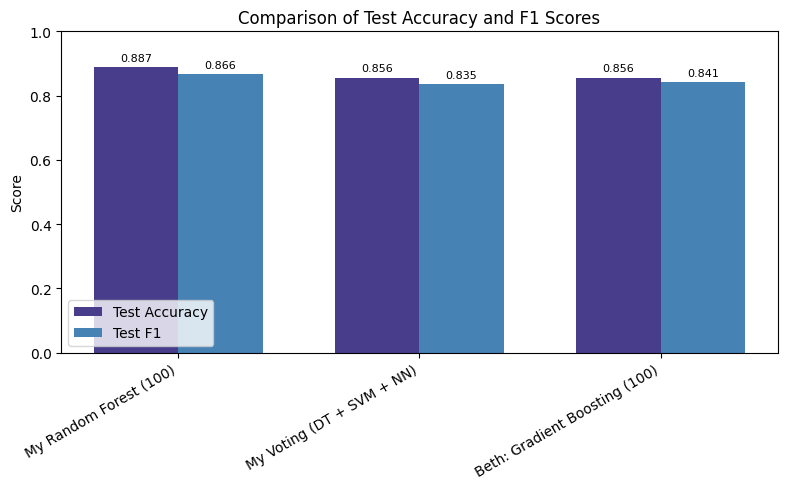

In [42]:
# Combine my results and Beth's results
data = {
    "Model": [
        "My Random Forest (100)",
        "My Voting (DT + SVM + NN)",
        "Beth: Gradient Boosting (100)"
    ],
    "Test Accuracy": [0.8875, 0.85625, 0.85625],
    "Test F1": [0.866056, 0.835124, 0.841106]
}

df_plot = pd.DataFrame(data)

# Set up bar positions
x = np.arange(len(df_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

# Plot bars
rects1 = ax.bar(x - width/2, df_plot["Test Accuracy"], width, label="Test Accuracy", color="darkslateblue")
rects2 = ax.bar(x + width/2, df_plot["Test F1"], width, label="Test F1", color="steelblue")

# Labels, title, ticks
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title("Comparison of Test Accuracy and F1 Scores")
ax.set_xticks(x)
ax.set_xticklabels(df_plot["Model"], rotation=30, ha="right")
ax.legend()

# Add values on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

- My Random Forest did better than both of those ensembles, hitting 0.8875 accuracy on the test set.

- Beth’s Gradient Boosting (100) and my Voting ensemble ended up with similar accuracy (~0.85), but her model had a bigger train-test gap, while mine was a bit more conservative.

- Overall, seeing her results actually made me feel even more confident in Random Forest for this dataset. Even with different modeling approaches, it still came out on top for handling new data.

- If I had to choose a “best model” of the three, Random Forest is the winner.

### 7.3 Optional Next Steps

- Run Random Forest (200, max_depth=10)	which would add more trees, but limit tree depth to reduce overfitting.

- Scale and tune SVM, then re-run Voting model.

- Address any class imbalance and compare F1.

- Explore which features ( like alcohol and pH) consistently increase probability of high-quality label.
